In [ ]:
from ultralytics import YOLO

model = YOLO(r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\runs\detect\train\weights\best.pt")

In [ ]:
results = model.predict(
    source=r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\valid\images\1265099_png.rf.62c62a06d52c6bdfd9020d18cf7968c3.jpg",
    show=True,
)

In [ ]:
model.predict(
    source=0,   # 摄像头
    show=True
)

In [1]:
from ultralytics import YOLO
from collections import Counter
import cv2

# 1️⃣ 加载模型（改成你的路径）
model = YOLO(r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\runs\detect\train\weights\best.pt")

# 2️⃣ 读取图片
img_path = r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\test\images\00000737_jpg.rf.0ddf41ecb10c29d8937aa24ef3f129dd.jpg"
results = model(img_path)

# 3️⃣ 类别名称
names = model.names

# 4️⃣ 统计行为
counter = Counter()

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        counter[cls_id] += 1

# 5️⃣ 输出统计结果
print("===== 行为统计 =====")
for cls_id, count in counter.items():
    print(f"{names[cls_id]}: {count}")

# 6️⃣ 计算课堂指标（按你类别自己调整）
total = sum(counter.values())

# ⚠️ 这里需要你根据类别定义修改
attention_classes = ["raise_head", "writing", "upright","reading","hand-raising"]
abnormal_classes = ["sleep", "phone","turn_head","bow_head","bend","book"]

attention = sum(counter[i] for i in counter if names[i] in attention_classes)
abnormal = sum(counter[i] for i in counter if names[i] in abnormal_classes)

if total > 0:
    focus_rate = attention / total
    abnormal_rate = abnormal / total
else:
    focus_rate = 0
    abnormal_rate = 0

print("\n===== 课堂指标 =====")
print(f"专注度: {focus_rate:.2f}")
print(f"异常率: {abnormal_rate:.2f}")

# 7️⃣ 可视化结果（带框图片）
annotated = results[0].plot()

cv2.imshow("Result", annotated)
cv2.waitKey(0)
cv2.destroyAllWindows()


image 1/1 E:\\\Student Behaviour Detection.v6i.yolov8\test\images\00000737_jpg.rf.0ddf41ecb10c29d8937aa24ef3f129dd.jpg: 640x640 1 Using_phone, 1 bend, 3 books, 2 bow_heads, 4 phones, 6 raise_heads, 1 sleep, 8 uprights, 136.2ms
Speed: 4.8ms preprocess, 136.2ms inference, 18.0ms postprocess per image at shape (1, 3, 640, 640)
===== 行为统计 =====
bend: 1
upright: 8
book: 3
bow_head: 2
raise_head: 6
Using_phone: 1
sleep: 1
phone: 4

===== 课堂指标 =====
专注度: 0.54
异常率: 0.42


Using_phone： 使用手机
bend' ： 弯腰
book ：看书
bow_head：低头
hand-raising ：举手
phone ：打电话
raise_head :抬头
reading ：阅读
sleep ： 睡觉
turn_head ：砖头
upright ：直立
writing ：写作

In [ ]:
from ultralytics import YOLO
from collections import Counter
import cv2
import matplotlib.pyplot as plt
# ===== 1️⃣ 加载模型 =====
model = YOLO(r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\runs\detect\train\weights\best.pt")
# ===== 2️⃣ 视频读取 =====
# cap = cv2.VideoCapture("classroom.mp4")
cap = cv2.VideoCapture(1)   # 0 = 默认摄像头

names = model.names
# ===== 3️⃣ 存储专注度 =====
focus_list = []
frame_id = 0
# ⚠️ 根据你的类别改
attention_classes = ["raise_head", "writing", "upright","reading","hand-raising"]
abnormal_classes = ["sleep", "phone","turn_head","bow_head","bend","book"]
# ===== 4️⃣ 开始处理视频 =====
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame)
    counter = Counter()
    # ===== 统计行为 =====
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            counter[cls_id] += 1
    # ===== 计算专注度 =====
    total = sum(counter.values())
    attention = sum(counter[i] for i in counter if names[i] in attention_classes)
    if total > 0:
        focus_rate = attention / total
    else:
        focus_rate = 0
    focus_list.append(focus_rate)
    # ===== 可视化 =====
    annotated = results[0].plot()
    cv2.putText(annotated, f"Focus: {focus_rate:.2f}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow("Classroom", annotated)
    if cv2.waitKey(1) & 0xFF == 27:
        break
    frame_id += 1
cap.release()
cv2.destroyAllWindows()
# ===== 5️⃣ 绘制专注度曲线 =====
plt.figure()
plt.plot(focus_list)
plt.xlabel("Frame")
plt.ylabel("Focus Rate")
plt.title("Classroom Focus Over Time")
plt.show()


0: 480x640 (no detections), 35.2ms
Speed: 11.6ms preprocess, 35.2ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 46.1ms
Speed: 2.3ms preprocess, 46.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 40.7ms
Speed: 1.6ms preprocess, 40.7ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 45.8ms
Speed: 1.5ms preprocess, 45.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 44.6ms
Speed: 1.5ms preprocess, 44.6ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 37.0ms
Speed: 1.1ms preprocess, 37.0ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 32.8ms
Speed: 0.9ms preprocess, 32.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 40.1ms
Speed: 1.3ms preprocess, 40.1ms 

In [27]:
from ultralytics import YOLO
from collections import Counter
import cv2
import matplotlib.pyplot as plt

# ===== 1️⃣ 加载模型 =====
model = YOLO(r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\runs\detect\train\weights\best.pt")
names = model.names

# ===== 2️⃣ 视频 =====
# cap = cv2.VideoCapture("classroom.mp4")
cap = cv2.VideoCapture(0)   # 0 = 默认摄像头

# ===== 3️⃣ 定义类别（⚠️必须改成你的）=====
attention_classes = ["raise_head", "writing", "listen", "upright"]
active_classes = ["raise_hand","writing"]
abnormal_classes = ["sleep", "phone","turn_head","bow_head","bend","book"]

#
# attention_classes = ["raise_head", "writing", "upright","reading","hand-raising"]
# abnormal_classes = ["sleep", "phone","turn_head","bow_head","bend","book"]


# ===== 4️⃣ 时间序列数据 =====
focus_list = []
active_list = []
abnormal_list = []

frame_id = 0
fps = cap.get(cv2.CAP_PROP_FPS)
interval = int(fps)  # 每秒统计一次

# ===== 5️⃣ 主循环 =====
while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)

    counter = Counter()

    # ===== 行为统计 =====
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            counter[cls_id] += 1

    total = sum(counter.values())

    # ===== 指标计算 =====
    attention = sum(counter[i] for i in counter if names[i] in attention_classes)
    active = sum(counter[i] for i in counter if names[i] in active_classes)
    abnormal = sum(counter[i] for i in counter if names[i] in abnormal_classes)

    focus_rate = attention / total if total > 0 else 0
    active_rate = active / total if total > 0 else 0
    abnormal_rate = abnormal / total if total > 0 else 0

    # ===== 每秒记录一次 =====
    if frame_id % interval == 0:
        focus_list.append(focus_rate)
        active_list.append(active_rate)
        abnormal_list.append(abnormal_rate)

    # ===== 显示（可选）=====
    annotated = results[0].plot()

    cv2.putText(annotated, f"Focus: {focus_rate:.2f}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.imshow("Classroom", annotated)

    if cv2.waitKey(1) & 0xFF == 27:
        break

    frame_id += 1

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

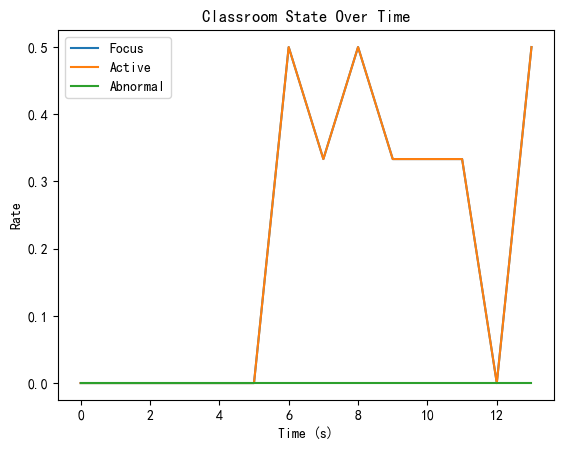

In [16]:
plt.figure()

plt.plot(focus_list, label="Focus")
plt.plot(active_list, label="Active")
plt.plot(abnormal_list, label="Abnormal")

plt.xlabel("Time (s)")
plt.ylabel("Rate")
plt.title("Classroom State Over Time")

plt.legend()
plt.show()

In [4]:
import numpy as np

focus_avg = np.mean(focus_list)
active_avg = np.mean(active_list)
abnormal_avg = np.mean(abnormal_list)

print("===== 课堂状态评估 =====")
print(f"平均专注度: {focus_avg:.2f}")
print(f"平均活跃度: {active_avg:.2f}")
print(f"平均异常率: {abnormal_avg:.2f}")

===== 课堂状态评估 =====
平均专注度: 0.37
平均活跃度: 0.37
平均异常率: 0.00


In [5]:
# 找最低点（注意力下降）
min_focus_time = focus_list.index(min(focus_list))

# 找最高点（互动高峰）
max_active_time = active_list.index(max(active_list))

print("\n===== 教学节奏分析 =====")
print(f"注意力最低点在第 {min_focus_time} 秒")
print(f"课堂最活跃在第 {max_active_time} 秒")


===== 教学节奏分析 =====
注意力最低点在第 3 秒
课堂最活跃在第 7 秒


In [6]:
print("\n===== 教学建议 =====")

if focus_avg < 0.6:
    print("建议：整体专注度较低，应增加互动环节")

if abnormal_avg > 0.2:
    print("建议：异常行为较多，建议加强课堂管理")

if min_focus_time > 10:
    print("建议：中后期注意力下降，建议调整节奏")


===== 教学建议 =====
建议：整体专注度较低，应增加互动环节


In [7]:
with open("report.txt", "w") as f:
    f.write("课堂分析报告\n")
    f.write(f"专注度: {focus_avg:.2f}\n")
    f.write(f"活跃度: {active_avg:.2f}\n")

最终版本--实时进行课堂分析


In [3]:
from ultralytics import YOLO
from collections import Counter
import cv2
import matplotlib.pyplot as plt
import serial
import time
import numpy as np

ser = serial.Serial('COM11', 115200, timeout=1)
time.sleep(2)  # 等ESP32启动

def send_to_esp32(focus_rate, active_rate, abnormal_rate):

    try:
        msg = f"F:{focus_rate:.2f},A1:{active_rate:.2f},B2:{abnormal_rate:.2f}\n"
        ser.write(msg.encode())
    except Exception as e:
        print("串口发送失败:", e)

def generate_smart_advice(focus_list, active_list, abnormal_list):
    advice = []
    focus = focus_list[-1]
    active = active_list[-1]
    abnormal = abnormal_list[-1]
    if len(focus_list) >= 5:
        trend = np.mean(focus_list[-5:]) - np.mean(focus_list[-10:-5]) if len(focus_list) >= 10 else 0
    else:
        trend = 0
    low_focus_duration = sum(1 for x in focus_list[-5:] if x < 0.5)
    if focus < 0.5 and low_focus_duration >= 3:
        advice.append("【重点】学生持续注意力较低，建议立即引入互动或提问环节")
    elif trend < -0.1:
        advice.append("【趋势】课堂专注度呈下降趋势，建议调整讲解节奏或增加案例")
    if abnormal > 0.3:
        advice.append("【管理】异常行为较多，建议加强课堂管理或点名提醒")
    if active > 0.4:
        advice.append("【良好】课堂互动较高，可以继续保持当前教学方式")
    if len(focus_list) > 20 and np.mean(focus_list[-5:]) < np.mean(focus_list[:5]):
        advice.append("【节奏】课堂后期注意力下降，建议安排总结或短暂放松")
    if not advice:
        advice.append("课堂状态良好，建议保持当前教学节奏")
    return advice
# =====加载模型 =====
model = YOLO(r"E:\小项目\五一前\Student Behaviour Detection.v6i.yolov8\runs\detect\train\weights\best.pt")
names = model.names
# =====视频 =====
# cap = cv2.VideoCapture("classroom.mp4")
cap = cv2.VideoCapture(1)   # 0 = 默认摄像头
# =====定义类别=====
attention_classes = ["raise_head", "writing", "listen", "upright"]
active_classes = ["raise_hand","writing"]
abnormal_classes = ["sleep", "phone","turn_head","bow_head","bend","book"]
# ===== 时间序列数据 =====
focus_list = []
active_list = []
abnormal_list = []
frame_id = 0
fps = cap.get(cv2.CAP_PROP_FPS)
interval = int(fps)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)

    counter = Counter()

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            counter[cls_id] += 1

    total = sum(counter.values())

    attention = sum(counter[i] for i in counter if names[i] in attention_classes)
    active = sum(counter[i] for i in counter if names[i] in active_classes)
    abnormal = sum(counter[i] for i in counter if names[i] in abnormal_classes)

    focus_rate = attention / total if total > 0 else 0
    active_rate = active / total if total > 0 else 0
    abnormal_rate = abnormal / total if total > 0 else 0

    # ===== 每秒更新 =====
    if frame_id % interval == 0:
        focus_list.append(focus_rate)
        active_list.append(active_rate)
        abnormal_list.append(abnormal_rate)
        advice = generate_smart_advice(focus_list, active_list, abnormal_list)
        print(f"\n===== 第 {len(focus_list)} 秒 =====")
        print(f"专注度: {focus_rate:.2f}")
        print(f"活跃度: {active_rate:.2f}")
        print(f"异常率: {abnormal_rate:.2f}")
        send_to_esp32(focus_rate, active_rate, abnormal_rate)
        print("\n===== 智能教学建议 =====")
        for a in advice:
            print(a)
    frame_id += 1
cap.release()
cv2.destroyAllWindows()

SerialException: could not open port 'COM11': PermissionError(13, '拒绝访问。', None, 5)

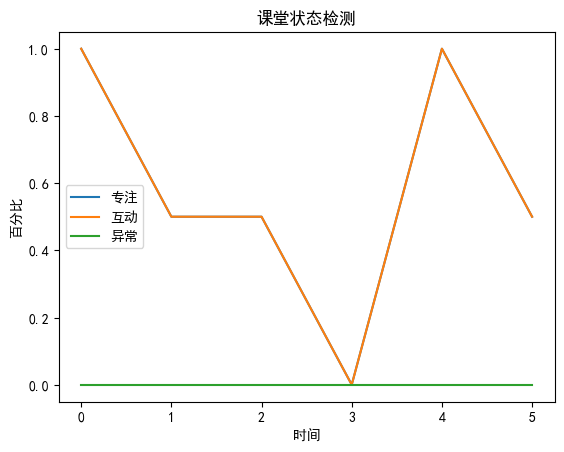

In [25]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.figure()
plt.plot(focus_list, label="专注")
plt.plot(active_list, label="互动")
plt.plot(abnormal_list, label="异常")
plt.xlabel("时间")
plt.ylabel("百分比")
plt.title("课堂状态检测")
plt.legend()
plt.show()

In [1]:
import numpy as np

focus_avg = np.mean(focus_list)
active_avg = np.mean(active_list)
abnormal_avg = np.mean(abnormal_list)

print("===== 课堂状态评估 =====")
print(f"平均专注度: {focus_avg:.2f}")
print(f"平均活跃度: {active_avg:.2f}")
print(f"平均异常率: {abnormal_avg:.2f}")

NameError: name 'focus_list' is not defined